In [ ]:
# ✅ استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
# ✅ تحميل البيانات
df= pd.read_csv('Reviews1.csv')

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
# ✅ عرض أول الصفوف
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266164 entries, 0 to 266163
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      266164 non-null  int64 
 1   ProductId               266164 non-null  object
 2   UserId                  266164 non-null  object
 3   ProfileName             266151 non-null  object
 4   HelpfulnessNumerator    266164 non-null  int64 
 5   HelpfulnessDenominator  266164 non-null  int64 
 6   Score                   266164 non-null  int64 
 7   Time                    266164 non-null  int64 
 8   Summary                 266154 non-null  object
 9   Text                    266164 non-null  object
dtypes: int64(5), object(5)
memory usage: 20.3+ MB


In [ ]:
df.isna().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,13
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,10
Text,0


In [ ]:

# Select useful columns
df = df[['Text', 'Score']].dropna()

# Convert Score into Sentiment
def convert_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(convert_sentiment)

# Basic info
print(df.info())
print(df['Sentiment'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266164 entries, 0 to 266163
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Text       266164 non-null  object
 1   Score      266164 non-null  int64 
 2   Sentiment  266164 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.1+ MB
None
Sentiment
Positive    206821
Negative     38644
Neutral      20699
Name: count, dtype: int64


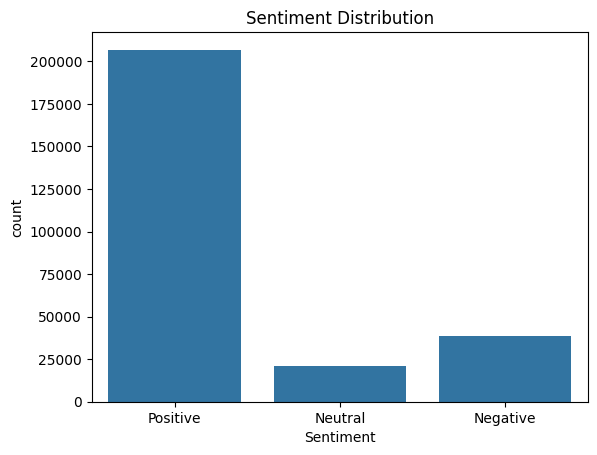

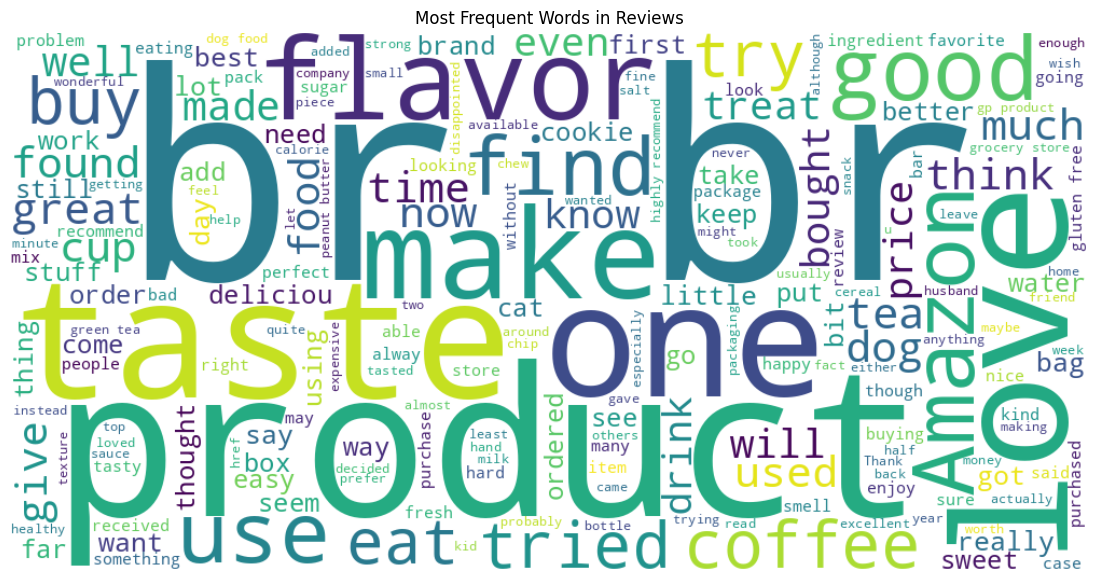

In [ ]:
# Sentiment distribution
sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution')
plt.show()

# WordCloud
from wordcloud import WordCloud

text = " ".join(df['Text'].astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Reviews")
plt.show()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['Text']
y = df['Sentiment']

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


Logistic Regression Report:
              precision    recall  f1-score   support

    Negative       0.74      0.65      0.69      7592
     Neutral       0.51      0.16      0.25      4228
    Positive       0.89      0.97      0.93     41413

    accuracy                           0.86     53233
   macro avg       0.71      0.59      0.62     53233
weighted avg       0.84      0.86      0.84     53233



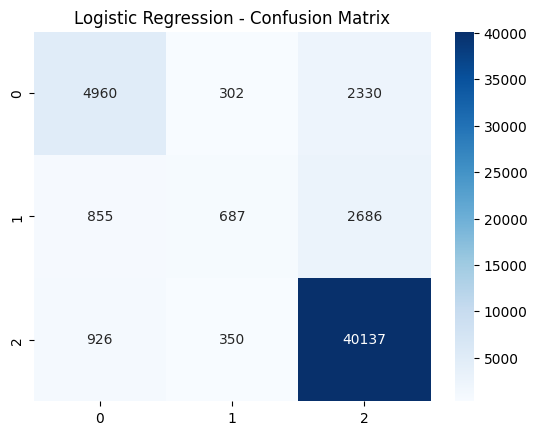

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd
import re
import spacy

# Load SpaCy English model and stop words
nlp = spacy.load("en_core_web_sm")
STOP_WORDS = nlp.Defaults.stop_words

# Read Amazon Fine Food Reviews
df = pd.read_csv("Reviews1.csv")

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:

# Select only the Text column and drop NA
reviews = df[['Text']].dropna().reset_index(drop=True)

In [ ]:
# ------------------ Step 1: Data Collection & Preprocessing ------------------


# Text cleaning function using spaCy only
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", "", text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
              if token.is_alpha and
                 token.text not in STOP_WORDS and
                 len(token.text) > 2]
    return " ".join(tokens)


In [ ]:
# Apply cleaning
tqdm_pbar = lambda iterable: iterable  # replace with tqdm if desired
reviews['clean_text'] = reviews['Text'].apply(clean_text)


In [ ]:
df['clean_text'] = reviews['clean_text']

In [ ]:
df['clean_text']

,clean_text
0,buy vitality can dog food product find good qu...
1,product arrived label jumbo salt peanutsthe pe...
2,confection century light pillowy citrus gelati...
3,look secret ingredient robitussin believe find...
4,great taffy great price wide assortment yummy ...
...,...
16238,product original package individual kcup loose...
16239,strong bitter coffee find cup like strong coff...
16240,love green mountain coffee taste great keurig ...
16241,good price excellent coffee pack perfect cent ...


In [ ]:
# Save cleaned dataset
reviews.to_csv("cleaned_amazon_reviews.csv", index=False)


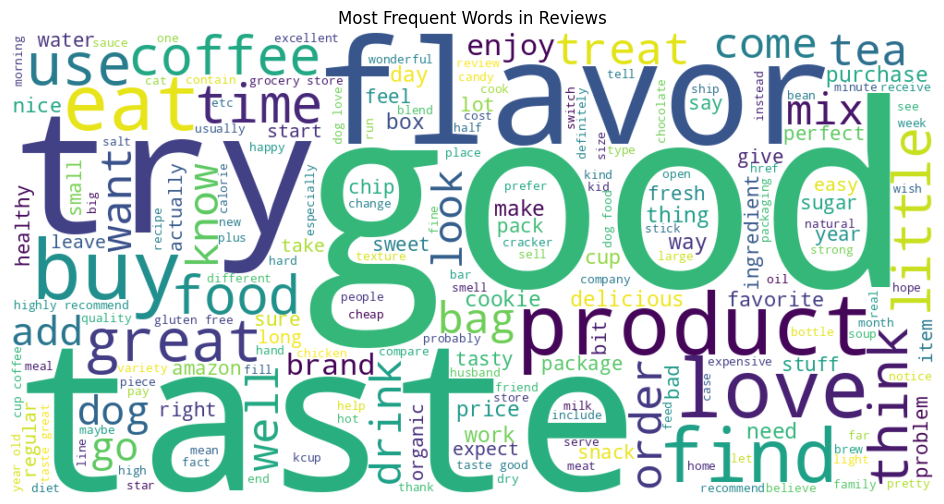

In [ ]:
# ------------------ Step 2: Exploratory Data Analysis (EDA) ------------------

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load cleaned data
df_clean = pd.read_csv("cleaned_amazon_reviews.csv")

# Generate WordCloud
text = " ".join(df_clean['clean_text'].astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Reviews")
plt.show()


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,clean_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...,buy vitality can dog food product find good qu...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived label jumbo salt peanutsthe pe...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...,confection century light pillowy citrus gelati...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...,look secret ingredient robitussin believe find...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [ ]:
# ------------------ Step 3: Sentiment Classification ------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare sentiment labels from original scores
full_df = df[['Score', 'Text']].dropna().reset_index(drop=True)
full_df['sentiment'] = full_df['Score'].apply(
    lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral')
)

# Merge with cleaned text
full_df = full_df.merge(reviews[['Text', 'clean_text']], on='Text')

# Feature extraction
X = full_df['clean_text']
y = full_df['sentiment']
vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)


Logistic Regression Report:
               precision    recall  f1-score   support

    negative       0.79      0.54      0.64       501
     neutral       0.78      0.18      0.29       295
    positive       0.86      0.98      0.92      2708

    accuracy                           0.85      3504
   macro avg       0.81      0.57      0.61      3504
weighted avg       0.84      0.85      0.82      3504



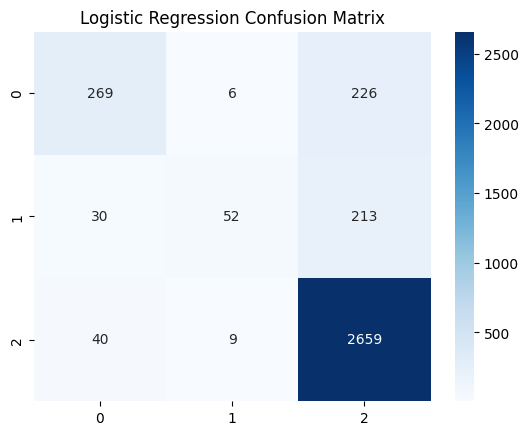

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap='Blues', fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


Random Forest Report:
               precision    recall  f1-score   support

    negative       0.86      0.36      0.50       501
     neutral       0.98      0.18      0.30       295
    positive       0.83      0.99      0.90      2708

    accuracy                           0.83      3504
   macro avg       0.89      0.51      0.57      3504
weighted avg       0.85      0.83      0.80      3504



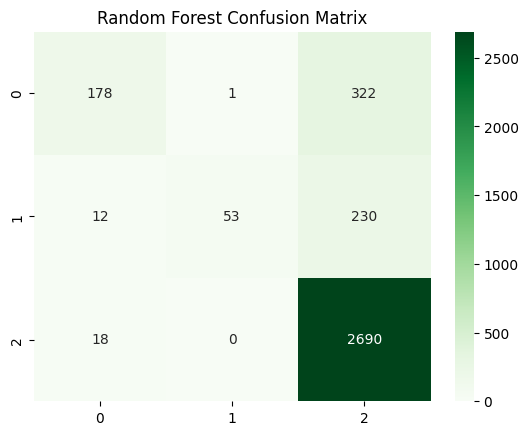

In [ ]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Greens', fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()